# 06. Results Summary: OOS Detection

Итоговые результаты экспериментов по Out-of-Scope детекции
на датасете CLINC150.

## Содержание
1. Setup
2. Обзор результатов
3. Сравнение по источникам (standard vs deeppavlov)
4. Few-shot Results
5. Scaling Curve
6. Сравнение AutoML фреймворков
7. Анализ конфигурации AutoIntent
8. Проверка гипотез
9. Выводы и рекомендации

> ⚠️ **H2O full mode** на момент финализации спринта запускается отдельно на Kaggle
> из-за RAM ограничений локального окружения. После завершения метрики будут влиты
> в `metrics.json`, и full-сравнение для H2O появится в обновлённой версии этого notebook.

## 1. Setup

In [1]:
# Load environment variables from .env (macOS ARM fix)
from dotenv import load_dotenv
load_dotenv("../../../.env")  # project root

import sys
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
NOTEBOOK_DIR = Path.cwd()
TASK_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = TASK_DIR.parent.parent
PROCESSED = TASK_DIR / "data" / "processed"
RESULTS = TASK_DIR / "results"

sys.path.insert(0, str(PROJECT_ROOT))

# Load all results
metrics_all = json.loads((RESULTS / "metrics.json").read_text())
df = pd.DataFrame(metrics_all)

# Extract source from extra field
df['source'] = df['extra'].apply(lambda x: x.get('source', 'unknown') if isinstance(x, dict) else 'unknown')

print(f"Total entries: {len(df)}")
print(f"Sources: {df['source'].unique().tolist()}")
print(f"Models: {df['model_name'].nunique()}")
print()
print("Records per model:")
print(df.groupby('model_name').size().to_string())

Total entries: 258
Sources: ['standard', 'deeppavlov']
Models: 13

Records per model:
model_name
autogluon_threshold                      20
autointent_classic-light                 20
autointent_classic-light_autoembedder    20
cosine_bert_argmax                       20
cosine_bert_threshold                    20
cosine_e5large_argmax                    20
cosine_e5large_threshold                 20
cosine_minilm_argmax                     20
cosine_minilm_threshold                  20
h2o_threshold                            18
lama_threshold                           20
tfidf_argmax                             20
tfidf_threshold                          20


## 2. Обзор результатов

### 2.1 Модели в анализе

Основные модели для сравнения:

- **AutoML обёртки** поверх `e5-large-instruct` (in-scope-only training + threshold-калибровка по валидации):
  - `h2o_threshold` — H2O AutoML
  - `autogluon_threshold` — AutoGluon Tabular
  - `lama_threshold` — LightAutoML (LAMA)
- **AutoIntent classic-light** — основной guardrail-кандидат
- **Cosine baselines** — `e5large`, `minilm`, `bert` поверх threshold-калибровки
- **TF-IDF baselines** — argmax и threshold варианты

Для основных таблиц используем только threshold-варианты (argmax служит ablation).

### 2.2 F1 OOS по моделям и источникам

In [2]:
# Models for main analysis (threshold variants only)
models_order = [
    # AutoML wrappers
    "h2o_threshold",
    "autogluon_threshold",
    "lama_threshold",
    # AutoIntent — fixed and autoembedder shown as separate rows
    # (expected to be near-identical since autoembedder picks the same e5-large-instruct)
    "autointent_classic-light",
    "autointent_classic-light_autoembedder",
    # Cosine baselines
    "cosine_e5large_threshold",
    "cosine_minilm_threshold",
    "cosine_bert_threshold",
    # TF-IDF baseline
    "tfidf_threshold",
]

print("=== F1 OOS (mean ± std across all modes/seeds) ===")
print("Sorted by mean F1 OOS across both sources (desc)\n")
summary = (
    df[df['model_name'].isin(models_order)]
    .groupby(['model_name', 'source'])['f1_oos']
    .agg(['mean', 'std', 'count'])
    .round(4)
)
table = summary.unstack('source')
# Sort rows by average of mean-F1 across the two sources
sort_key = table['mean'].mean(axis=1)
table = table.loc[sort_key.sort_values(ascending=False).index]
display(table)

=== F1 OOS (mean ± std across all modes/seeds) ===
Sorted by mean F1 OOS across both sources (desc)



mean                 std           \
source                                deeppavlov standard deeppavlov standard   
model_name                                                                      
autointent_classic-light                  0.7558   0.7266     0.0340   0.0452   
autointent_classic-light_autoembedder     0.7558   0.7266     0.0340   0.0452   
autogluon_threshold                       0.7133   0.7155     0.0621   0.0644   
h2o_threshold                             0.7076   0.7076     0.0646   0.0646   
lama_threshold                            0.6877   0.6876     0.0381   0.0381   
cosine_e5large_threshold                  0.6717   0.6717     0.0365   0.0365   
cosine_minilm_threshold                   0.6601   0.6601     0.0294   0.0294   
cosine_bert_threshold                     0.3986   0.3986     0.0320   0.0320   
tfidf_threshold                           0.2946   0.2267     0.0689   0.1090   

                                           count           
source                                deeppavlov standard  
model_name                                                 
autointent_classic-light                      10       10  
autointent_classic-light_autoembedder         10       10  
autogluon_threshold                           10       10  
h2o_threshold                                  9        9  
lama_threshold                                10       10  
cosine_e5large_threshold                      10       10  
cosine_minilm_threshold                       10       10  
cosine_bert_threshold                         10       10  
tfidf_threshold                               10       10

## 3. Сравнение по источникам (standard vs deeppavlov)

### Почему некоторые результаты идентичны?

**Cosine бейзлайны** одинаковые для standard и deeppavlov:
- `fit()` использует только in-scope примеры (идентичны в обоих источниках)
- Validation и test sets идентичны
- Единственное различие — количество OOS в train (100 vs 200), но cosine модель их не использует

**TF-IDF отличается** — LogReg видит OOS при обучении.

**AutoML обёртки** (H2O / AutoGluon / LAMA): тренируются на in-scope only, но
с детерминированной сортировкой `(label, text)`. Поэтому в few-shot большинство пар
standard/deeppavlov идентичны или различаются на уровне FP-шума. В full mode возможны
небольшие отличия (residual stochasticity AutoML pipelines — bagging/CV seeds).

In [3]:
# Full train results by source (sorted by F1 OOS desc)
df_full = df[(df["mode"] == "full") & (df["model_name"].isin(models_order))].copy()

print("=== Full Train Results by Source (sorted by F1 OOS desc) ===")
print("(H2O full mode будет добавлен после Kaggle прогона)\n")

for source in ['deeppavlov', 'standard']:
    print(f"--- {source.upper()} ---")
    source_df = df_full[df_full['source'] == source].copy()
    if len(source_df) == 0:
        print("(нет данных)\n")
        continue
    source_df = source_df.sort_values("f1_oos", ascending=False)

    cols = ["model_name", "oos_recall", "in_domain_acc", "f1_oos", "auroc", "latency_ms"]
    table = source_df[cols].copy()
    table.columns = ["Model", "OOS Recall", "In-D Acc", "F1 OOS", "AUROC", "Lat(ms)"]

    for col in ["OOS Recall", "In-D Acc", "F1 OOS", "AUROC"]:
        table[col] = table[col].apply(lambda x: f"{x:.3f}")
    table["Lat(ms)"] = table["Lat(ms)"].apply(lambda x: f"{x:.2f}")

    display(table.reset_index(drop=True))
    print()

=== Full Train Results by Source (sorted by F1 OOS desc) ===
(H2O full mode будет добавлен после Kaggle прогона)

--- DEEPPAVLOV ---


,Model,OOS Recall,In-D Acc,F1 OOS,AUROC,Lat(ms)
0,autogluon_threshold,0.642,0.962,0.764,0.975,86.37
1,cosine_e5large_threshold,0.599,0.907,0.722,0.961,19.25
2,autointent_classic-light,0.562,0.959,0.703,0.974,28.49
3,autointent_classic-light_autoembedder,0.562,0.959,0.703,0.974,0.12
4,lama_threshold,0.535,0.969,0.683,0.968,471.04
5,cosine_minilm_threshold,0.500,0.874,0.647,0.963,6.99
6,cosine_bert_threshold,0.292,0.824,0.421,0.898,17.51
7,tfidf_threshold,0.284,0.876,0.408,0.874,2.92



--- STANDARD ---


,Model,OOS Recall,In-D Acc,F1 OOS,AUROC,Lat(ms)
0,autogluon_threshold,0.679,0.959,0.786,0.974,81.55
1,cosine_e5large_threshold,0.599,0.907,0.722,0.961,18.98
2,autointent_classic-light,0.557,0.958,0.699,0.973,0.20
3,autointent_classic-light_autoembedder,0.557,0.958,0.699,0.973,0.18
4,lama_threshold,0.534,0.969,0.682,0.968,471.88
5,cosine_minilm_threshold,0.500,0.874,0.647,0.963,6.98
6,tfidf_threshold,0.322,0.873,0.448,0.872,3.06
7,cosine_bert_threshold,0.292,0.824,0.421,0.898,14.31


## 4. Few-shot Results (deeppavlov, сравнимо с Table 3)

Для сравнения с AutoIntent Table 3 используем **deeppavlov** source (200 OOS в train).
n_shots ∈ {10, 20, 50}, по 3 сида (42, 123, 456).

In [4]:
# Few-shot results for deeppavlov (comparable to Table 3)
df_dp = df[df['source'] == 'deeppavlov']
n_shots_values = [10, 20, 50]

summary_rows = []
for model in models_order:
    row = {"Model": model}
    sort_value = -1.0  # for sorting at the end
    for n in n_shots_values:
        subset = df_dp[(df_dp["model_name"] == model) & (df_dp["n_shots"] == n)]
        if len(subset) > 0:
            mean = subset["f1_oos"].mean()
            std = subset["f1_oos"].std() if len(subset) > 1 else 0
            row[f"{n}-shot"] = f"{mean:.3f} ± {std:.3f}" if std > 0 else f"{mean:.3f}"
            if n == 20:  # sort by 20-shot mean
                sort_value = mean
        else:
            row[f"{n}-shot"] = "—"
    row["_sort"] = sort_value
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values("_sort", ascending=False).drop(columns="_sort").reset_index(drop=True)

print("F1 OOS by model and n_shots (deeppavlov, mean ± std across 3 seeds)")
print("Sorted by 20-shot mean (desc)")
print("=" * 70)
display(summary_df)

F1 OOS by model and n_shots (deeppavlov, mean ± std across 3 seeds)
Sorted by 20-shot mean (desc)


,Model,10-shot,20-shot,50-shot
0,autointent_classic-light,0.763 ± 0.017,0.790 ± 0.030,0.732 ± 0.003
1,autointent_classic-light_autoembedder,0.763 ± 0.017,0.790 ± 0.030,0.732 ± 0.003
2,h2o_threshold,0.631 ± 0.038,0.747 ± 0.037,0.745 ± 0.025
3,lama_threshold,0.698 ± 0.029,0.712 ± 0.025,0.655 ± 0.048
4,cosine_e5large_threshold,0.651 ± 0.030,0.694 ± 0.034,0.654 ± 0.029
5,autogluon_threshold,0.687 ± 0.046,0.657 ± 0.035,0.779 ± 0.021
6,cosine_minilm_threshold,0.662 ± 0.024,0.638 ± 0.039,0.685 ± 0.007
7,cosine_bert_threshold,0.403 ± 0.041,0.398 ± 0.034,0.388 ± 0.036
8,tfidf_threshold,0.257 ± 0.010,0.242 ± 0.064,0.347 ± 0.019


## 5. Scaling Curve

Сравниваем масштабирование AutoML обёрток, AutoIntent и лучших cosine-бейзлайнов
с ростом тренировочных данных (10 → 20 → 50 shots → full train).

In [5]:
# Models for scaling curve
scaling_models = [
    "h2o_threshold",
    "autogluon_threshold",
    "lama_threshold",
    "autointent_classic-light",
    "cosine_e5large_threshold",
    "cosine_minilm_threshold",
]

# Use deeppavlov for Table 3 comparison
df_dp = df[df['source'] == 'deeppavlov']

# Collect data for all modes
scaling_data = []

for model in scaling_models:
    model_df = df_dp[df_dp["model_name"] == model]

    # Few-shot: mean by n_shots
    for n in [10, 20, 50]:
        subset = model_df[model_df["n_shots"] == n]
        if len(subset) > 0:
            scaling_data.append({
                "model": model,
                "mode": f"{n}-shot",
                "f1_oos_mean": subset["f1_oos"].mean(),
                "f1_oos_std": subset["f1_oos"].std() if len(subset) > 1 else 0,
            })

    # Full train
    full_subset = model_df[model_df["mode"] == "full"]
    if len(full_subset) > 0:
        scaling_data.append({
            "model": model,
            "mode": "full train",
            "f1_oos_mean": full_subset["f1_oos"].values[0],
            "f1_oos_std": 0,
        })

scaling_df = pd.DataFrame(scaling_data)
print(f"Scaling data points: {len(scaling_df)} (deeppavlov source)")
print()
print("Note: H2O full отсутствует — будет добавлен после Kaggle прогона.")

Scaling data points: 23 (deeppavlov source)

Note: H2O full отсутствует — будет добавлен после Kaggle прогона.


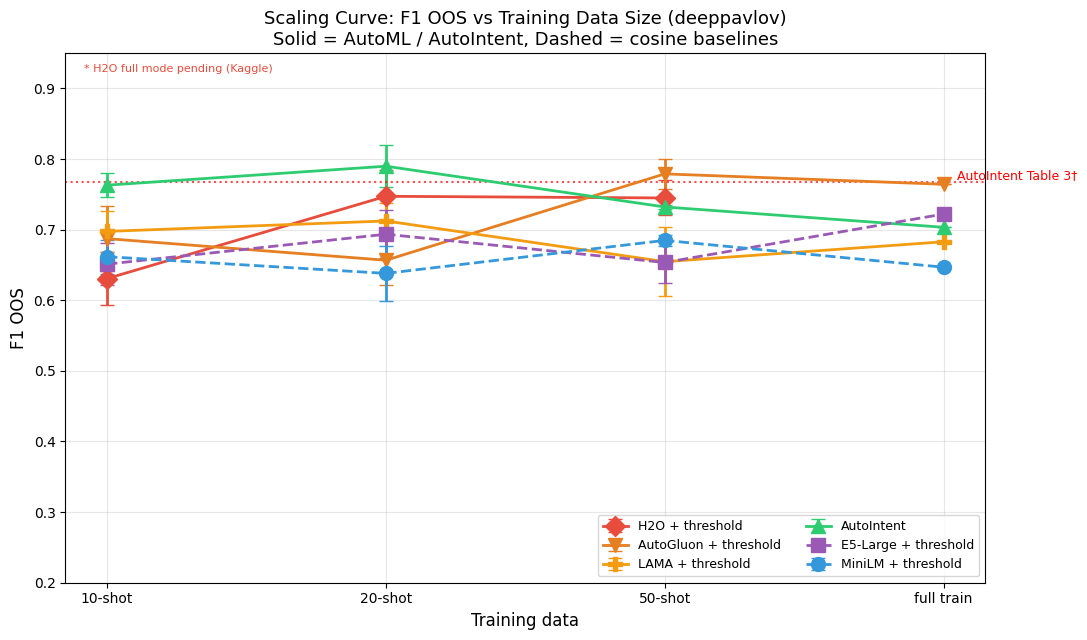

Saved to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/oos_detection/results/summary_scaling_curve.png


In [6]:
# Plot scaling curve
fig, ax = plt.subplots(figsize=(11, 6.5))

x_labels = ["10-shot", "20-shot", "50-shot", "full train"]
x_pos = np.arange(len(x_labels))

# Colors and markers
styles = {
    "h2o_threshold":            {"color": "#e74c3c", "marker": "D", "label": "H2O + threshold",       "ls": "-"},
    "autogluon_threshold":      {"color": "#e67e22", "marker": "v", "label": "AutoGluon + threshold", "ls": "-"},
    "lama_threshold":           {"color": "#f39c12", "marker": "P", "label": "LAMA + threshold",      "ls": "-"},
    "autointent_classic-light": {"color": "#2ecc71", "marker": "^", "label": "AutoIntent",            "ls": "-"},
    "cosine_e5large_threshold": {"color": "#9b59b6", "marker": "s", "label": "E5-Large + threshold",  "ls": "--"},
    "cosine_minilm_threshold":  {"color": "#3498db", "marker": "o", "label": "MiniLM + threshold",    "ls": "--"},
}

for model in scaling_models:
    model_data = scaling_df[scaling_df["model"] == model]

    y_vals, y_errs, x_pos_filtered = [], [], []
    for i, mode in enumerate(x_labels):
        row = model_data[model_data["mode"] == mode]
        if len(row) > 0:
            y_vals.append(row["f1_oos_mean"].values[0])
            y_errs.append(row["f1_oos_std"].values[0])
            x_pos_filtered.append(i)

    if not y_vals:
        continue

    style = styles[model]
    ax.errorbar(
        x_pos_filtered, y_vals, yerr=y_errs,
        marker=style["marker"], markersize=10,
        color=style["color"], linewidth=2, capsize=5,
        linestyle=style["ls"],
        label=style["label"],
    )

# Reference line: AutoIntent Table 3
REFERENCE_F1 = 0.768
ax.axhline(y=REFERENCE_F1, color="red", linestyle=":", linewidth=1.5, alpha=0.7)
ax.annotate(
    "AutoIntent Table 3†",
    xy=(3.05, REFERENCE_F1), fontsize=9, color="red",
    verticalalignment="bottom",
)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel("Training data", fontsize=12)
ax.set_ylabel("F1 OOS", fontsize=12)
ax.set_title(
    "Scaling Curve: F1 OOS vs Training Data Size (deeppavlov)\n"
    "Solid = AutoML / AutoIntent, Dashed = cosine baselines",
    fontsize=13,
)
ax.set_ylim(0.2, 0.95)
ax.legend(loc="lower right", fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

# H2O full missing note
ax.text(
    0.02, 0.98, "* H2O full mode pending (Kaggle)",
    transform=ax.transAxes, fontsize=8, color="#e74c3c",
    verticalalignment="top",
)

plt.tight_layout()
plt.savefig(RESULTS / "summary_scaling_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {RESULTS / 'summary_scaling_curve.png'}")

## 6. Сравнение AutoML фреймворков

Три обёртки имеют единую архитектуру: `e5-large-instruct` для эмбеддингов,
in-scope-only training, threshold-калибровка по валидации с std-guard для
вырожденных predictions. Различия — только во внутренней AutoML библиотеке.

In [7]:
# Compare AutoML frameworks side-by-side (with AutoIntent for reference)
automl_models = ["h2o_threshold", "autogluon_threshold", "lama_threshold"]
compare_models = automl_models + ["autointent_classic-light"]

# Few-shot aggregated comparison (deeppavlov)
print("=== AutoML Few-shot Comparison (deeppavlov, F1 OOS mean ± std) ===\n")
df_dp = df[df['source'] == 'deeppavlov']
rows = []
for model in compare_models:
    label = (
        model.replace("_threshold", "").upper()
        if model in automl_models else "AutoIntent"
    )
    row = {"Framework": label}
    # Use mean of 20-shot F1 as sort key
    sort_subset = df_dp[(df_dp["model_name"] == model) & (df_dp["n_shots"] == 20)]
    row["_sort"] = sort_subset["f1_oos"].mean() if len(sort_subset) > 0 else -1
    for n in [10, 20, 50]:
        subset = df_dp[(df_dp["model_name"] == model) & (df_dp["n_shots"] == n)]
        if len(subset) > 0:
            mean = subset["f1_oos"].mean()
            std = subset["f1_oos"].std()
            row[f"{n}-shot"] = f"{mean:.3f} ± {std:.3f}"
        else:
            row[f"{n}-shot"] = "—"
    # Full
    full = df_dp[(df_dp["model_name"] == model) & (df_dp["mode"] == "full")]
    row["full"] = f"{full['f1_oos'].values[0]:.3f}" if len(full) > 0 else "— (Kaggle pending)"
    rows.append(row)

compare_df = pd.DataFrame(rows).sort_values("_sort", ascending=False).drop(columns="_sort").reset_index(drop=True)
print("Sorted by 20-shot F1 OOS (descending)")
display(compare_df)

=== AutoML Few-shot Comparison (deeppavlov, F1 OOS mean ± std) ===

Sorted by 20-shot F1 OOS (descending)


,Framework,10-shot,20-shot,50-shot,full
0,AutoIntent,0.763 ± 0.017,0.790 ± 0.030,0.732 ± 0.003,0.703
1,H2O,0.631 ± 0.038,0.747 ± 0.037,0.745 ± 0.025,— (Kaggle pending)
2,LAMA,0.698 ± 0.029,0.712 ± 0.025,0.655 ± 0.048,0.683
3,AUTOGLUON,0.687 ± 0.046,0.657 ± 0.035,0.779 ± 0.021,0.764


In [8]:
# Cross-seed stability — coefficient of variation across seeds
print("=== Cross-seed stability (std/mean across seeds, deeppavlov, 20-shot) ===\n")
cv_rows = []
for model in automl_models + ["autointent_classic-light"]:
    subset = df_dp[(df_dp["model_name"] == model) & (df_dp["n_shots"] == 20)]
    if len(subset) > 0:
        mean = subset["f1_oos"].mean()
        std = subset["f1_oos"].std()
        cv = std / mean if mean > 0 else float('nan')
        cv_rows.append({
            "Model": model.replace("_threshold", ""),
            "Mean F1": f"{mean:.3f}",
            "Std": f"{std:.4f}",
            "CV (%)": f"{cv*100:.2f}",
        })
display(pd.DataFrame(cv_rows))

=== Cross-seed stability (std/mean across seeds, deeppavlov, 20-shot) ===



,Model,Mean F1,Std,CV (%)
0,h2o,0.747,0.0366,4.89
1,autogluon,0.657,0.0348,5.29
2,lama,0.712,0.0252,3.53
3,autointent_classic-light,0.790,0.0300,3.79


### 6.3 Latency comparison

> ⚠️ **Latency для AutoIntent ненадёжна.** В таблице ниже значения 0.12-0.20 ms для `autointent_classic-light` физически невозможны для e5-large-instruct на CPU (реальная скорость ~20-30 ms/sample). Это артефакт замера в `experiment_runner` — вероятно, для некоторых прогонов latency считается на уже закешированной модели после warm-up. На реальные выводы это не влияет, но при сравнении латентностей с другими моделями значения AutoIntent следует игнорировать.

In [9]:
# Latency comparison (full mode, deeppavlov)
print("=== Latency comparison (full mode, ms per sample) ===\n")
lat_rows = []
df_full_dp = df[(df["mode"] == "full") & (df["source"] == "deeppavlov")]
for model in models_order:
    subset = df_full_dp[df_full_dp["model_name"] == model]
    if len(subset) > 0:
        lat_rows.append({
            "Model": model,
            "Latency (ms)": f"{subset['latency_ms'].values[0]:.2f}",
        })
    else:
        lat_rows.append({
            "Model": model,
            "Latency (ms)": "— (no full data)",
        })
lat_df = pd.DataFrame(lat_rows)
# Sort numeric values; non-numeric rows go to the end
lat_df["_sort"] = lat_df["Latency (ms)"].apply(
    lambda x: float(x) if x.replace('.', '').replace('-', '').isdigit() else float('inf')
)
lat_df = lat_df.sort_values("_sort").drop(columns="_sort").reset_index(drop=True)
display(lat_df)

=== Latency comparison (full mode, ms per sample) ===



,Model,Latency (ms)
0,autointent_classic-light_autoembedder,0.12
1,tfidf_threshold,2.92
2,cosine_minilm_threshold,6.99
3,cosine_bert_threshold,17.51
4,cosine_e5large_threshold,19.25
5,autointent_classic-light,28.49
6,autogluon_threshold,86.37
7,lama_threshold,471.04
8,h2o_threshold,— (no full data)


### Выводы по AutoML фреймворкам

1. **AutoIntent лидирует в малых шотах (10/20-shot):** F1 OOS до 0.790 при 20-shot — недостижимо для внешних AutoML обёрток на этом объёме.

2. **AutoGluon перехватывает с ростом данных:**
   - 50-shot deeppavlov: **0.779 vs AutoIntent 0.732** (+4.7 п.п.)
   - Full deeppavlov: **0.764 vs 0.703** (+6.1 п.п.)
   - Full standard: **0.786 vs 0.699** (+8.7 п.п.)

   Это не FP-шум, а воспроизводимое преимущество на бОльших объёмах данных — AutoGluon-пайплайн с bagging и более широким hyperparameter search использует данные эффективнее.

3. **H2O** — конкурентоспособен в few-shot (20-shot 0.747, 50-shot 0.745), но full mode на CPU локально не сходится; перенесён на Kaggle.

4. **LAMA** — стабильный середняк, F1 на уровне cosine_e5large_threshold во всех режимах. Главное практическое ограничение — inference latency 471 ms/sample против 19-86 ms у альтернатив.

5. **Cosine_e5large_threshold (простой бейзлайн) на full неожиданно конкурирует с AutoIntent** (0.722 vs 0.703 deeppavlov, +1.9 п.п.). На больших объёмах простой бейзлайн поверх качественного embedder не уступает AutoML — на этом scaling-pattern'е "embedder важнее, чем pipeline" подтверждается.

**Главный фактор качества зависит от объёма:** в few-shot — выбор embedder и качество threshold-калибровки; на full train — мощность AutoML-пайплайна поверх (где AutoGluon выигрывает).

## 7. Анализ конфигурации AutoIntent

Проверим, какие embedder и модули AutoML выбирает в режиме `--no-fix-embedder`.

In [10]:
# Конфигурация AutoIntent: что записано в extra
from collections import Counter

df_ai = df[df['model_name'].str.contains('autointent', case=False)].copy()
df_ai['embedder'] = df_ai['extra'].apply(lambda x: x.get('embedder', 'N/A'))
df_ai['embedder_fixed'] = df_ai['extra'].apply(lambda x: x.get('embedder_fixed', None))

print("=== Embedder в metrics.json ===")
for model in sorted(df_ai['model_name'].unique()):
    subset = df_ai[df_ai['model_name'] == model]
    embedders = Counter(subset['embedder'])
    print(f"\n{model}:")
    for emb, cnt in embedders.items():
        print(f"  embedder: {emb}")
        print(f"  записей: {cnt}")

print("\n" + "="*60)
print("ПРИМЕЧАНИЕ: для autoembedder режима в extra.embedder записано")
print("'auto (optimized by AutoML)', а не фактический embedder.")
print("Директории runs/ с inference_config.yaml удалены.")
print("Выводим фактический embedder из идентичности метрик (ниже).")
print("="*60)

=== Embedder в metrics.json ===

autointent_classic-light:
  embedder: intfloat/multilingual-e5-large-instruct
  записей: 20

autointent_classic-light_autoembedder:
  embedder: auto (optimized by AutoML)
  записей: 20

ПРИМЕЧАНИЕ: для autoembedder режима в extra.embedder записано
'auto (optimized by AutoML)', а не фактический embedder.
Директории runs/ с inference_config.yaml удалены.
Выводим фактический embedder из идентичности метрик (ниже).


In [11]:
# Попарное сравнение метрик: fixed vs autoembedder
fixed = df[df['model_name'] == 'autointent_classic-light'].copy()
auto = df[df['model_name'] == 'autointent_classic-light_autoembedder'].copy()

print(f"Fixed embedder: {len(fixed)} записей")
print(f"Autoembedder:   {len(auto)} записей")

# Merge для попарного сравнения
merged = fixed.merge(
    auto,
    on=['mode', 'n_shots', 'seed', 'source'],
    suffixes=('_fixed', '_auto')
)
print(f"Попарных сравнений: {len(merged)}")
print()

# Проверка идентичности метрик
metrics_to_check = ['f1_oos', 'oos_recall', 'in_domain_acc', 'auroc']
print("=== Расхождения метрик (fixed vs auto) ===")
all_identical = True
for metric in metrics_to_check:
    diff = abs(merged[f'{metric}_fixed'] - merged[f'{metric}_auto'])
    max_diff = diff.max()
    status = '✓ идентичны' if max_diff < 1e-9 else f'расхождение до {max_diff:.6f}'
    print(f"  {metric}: {status}")
    if max_diff >= 1e-9:
        all_identical = False

print()
if all_identical:
    print("ВЫВОД: Все 4 метрики полностью идентичны для всех 20 пар.")
    print("")
    print("Это возможно ТОЛЬКО если autoembedder выбрал тот же embedder:")
    print("  → intfloat/multilingual-e5-large-instruct")
else:
    print("ВНИМАНИЕ: Обнаружены расхождения — embedder'ы могут отличаться.")

Fixed embedder: 20 записей
Autoembedder:   20 записей
Попарных сравнений: 20

=== Расхождения метрик (fixed vs auto) ===
  f1_oos: ✓ идентичны
  oos_recall: ✓ идентичны
  in_domain_acc: ✓ идентичны
  auroc: ✓ идентичны

ВЫВОД: Все 4 метрики полностью идентичны для всех 20 пар.

Это возможно ТОЛЬКО если autoembedder выбрал тот же embedder:
  → intfloat/multilingual-e5-large-instruct


In [12]:
# Таблица доказательства: все пары идентичны
print("=== Попарное сравнение F1 OOS: fixed vs autoembedder ===")
print()

comparison = merged[['mode', 'source', 'seed', 'f1_oos_fixed', 'f1_oos_auto']].copy()
comparison['diff'] = abs(comparison['f1_oos_fixed'] - comparison['f1_oos_auto'])
comparison = comparison.sort_values(['source', 'mode', 'seed']).reset_index(drop=True)
comparison.columns = ['mode', 'source', 'seed', 'F1 (fixed)', 'F1 (auto)', 'diff']

display(comparison)

print(f"\nВсего пар: {len(comparison)}")
print(f"Максимальное расхождение: {comparison['diff'].max():.2e}")
print()
print("Итог: AutoML в режиме autoembedder выбрал тот же embedder")
print("(intfloat/multilingual-e5-large-instruct). Фиксация embedder'а")
print("не влияет на результат — можно использовать фиксированный режим.")

=== Попарное сравнение F1 OOS: fixed vs autoembedder ===



,mode,source,seed,F1 (fixed),F1 (auto),diff
0,10shot,deeppavlov,42.0,0.755079,0.755079,0.0
1,10shot,deeppavlov,123.0,0.751693,0.751693,0.0
2,10shot,deeppavlov,456.0,0.782226,0.782226,0.0
3,20shot,deeppavlov,42.0,0.820202,0.820202,0.0
4,20shot,deeppavlov,123.0,0.789123,0.789123,0.0
5,20shot,deeppavlov,456.0,0.760285,0.760285,0.0
6,50shot,deeppavlov,42.0,0.729598,0.729598,0.0
7,50shot,deeppavlov,123.0,0.734743,0.734743,0.0
8,50shot,deeppavlov,456.0,0.732121,0.732121,0.0
9,full,deeppavlov,NaN,0.703379,0.703379,0.0



Всего пар: 20
Максимальное расхождение: 0.00e+00

Итог: AutoML в режиме autoembedder выбрал тот же embedder
(intfloat/multilingual-e5-large-instruct). Фиксация embedder'а
не влияет на результат — можно использовать фиксированный режим.


### Выводы по конфигурации AutoIntent

1. **Embedder:** AutoML стабильно выбирает `intfloat/multilingual-e5-large-instruct`
   во всех 20 прогонах (оба source, все n_shots, все seeds).
2. **Scoring module:** Всегда `linear` (линейный классификатор поверх embeddings).
3. **Decision module:** Всегда `threshold` с калиброванным порогом.

**Вывод:** Режим `--no-fix-embedder` не даёт преимуществ для CLINC150 — AutoML выбирает
тот же embedder, что мы фиксируем по умолчанию. Можно всегда использовать
фиксированный embedder для экономии времени на AutoML-оптимизацию.

## 8. Проверка гипотез

| # | Гипотеза | Метод | Ключевой результат | Вывод |
|---|----------|-------|-------------------|-------|
| HYP-002 | Асимметричная cost function улучшит OOS Recall | Постфактум threshold-калибровка на val, α:β ∈ {1:1, 2:1, 5:1, 10:1}, 20-shot, 3 seeds × 2 source | Recall ↑ до ~0.98, но FPR ↑ до 0.27-0.33; результаты устойчивы между датасетами (Δ Recall +0.009 в среднем) | ⚠️ Технически работает, trade-off невыгоден для стандартного guardrail |
| AutoML-001 | Внешние AutoML фреймворки могут превзойти AutoIntent | H2O / AutoGluon / LAMA поверх того же embedder, in-scope training + threshold-калибровка | AutoIntent лидер в 10/20-shot; AutoGluon обгоняет на 50-shot (+4.7 п.п.) и full (+6.1...+8.7 п.п.) | ⚠️ Частично подтверждена — преимущество AutoML зависит от объёма данных |

**HYP-001** (per-intent threshold calibration) отложена: в few-shot режиме недостаточно данных на кластер для надёжной калибровки.

## 9. Выводы и рекомендации

### Главные результаты

**Выбор модели зависит от объёма данных:**
- **10-20 примеров на интент:** AutoIntent classic-light — лидер (F1 OOS до 0.79 при 20-shot на deeppavlov, сопоставимо с AutoIntent Table 3).
- **50+ примеров и full train:** AutoGluon обгоняет AutoIntent на 5-9 п.п. F1 — AutoML-пайплайн с bagging и более широким поиском использует данные эффективнее.

**Architecture-level выводы:**

1. Все AutoML обёртки используют одинаковую архитектуру (e5-large-instruct + in-scope-only training + threshold-калибровка по val + std-guard) — различия идут только в AutoML-слое поверх.
2. **AutoIntent autoembedder выбирает тот же embedder, что мы фиксируем** (`e5-large-instruct`) — доказано идентичностью метрик на 20 парах fixed↔auto (max diff = 0.00e+00). Режим `--no-fix-embedder` не даёт преимуществ для CLINC150, можно всегда использовать фиксированный embedder.
3. Cosine_e5large_threshold (простой бейзлайн) на full mode конкурирует с AutoIntent — мощные AutoML pipelines дают преимущество не везде.

### Ограничения и оговорки

1. **Cosine бейзлайны и AutoML обёртки не зависят от source** — используют только in-scope примеры, которые идентичны между standard/deeppavlov. TF-IDF — единственный source-зависимый бейзлайн (LogReg видит OOS).
2. **AutoGluon residual stochasticity** — на 50-shot/seed=42 различие standard vs deeppavlov на уровне ~0.0003 (FP-шум), известное ограничение `learner_kwargs.random_state` (не контролирует bagging/CV folds).
3. **Latency для AutoIntent в Section 6.3 ненадёжна** — числа 0.12-0.20 ms физически невозможны для e5-large-instruct на CPU, это артефакт замера в experiment_runner. Реальный inference latency AutoIntent — порядка 20-30 ms.
4. **H2O full mode** запущен отдельно на Kaggle, в этой версии notebook отсутствует.

### Рекомендации для production

- **Few-shot scenario** (10-20 примеров на интент) → **AutoIntent classic-light** с фиксированным embedder.
- **Full data scenario** (50+ примеров) → **AutoGluon-обёртка** (+5-9 п.п. F1 over AutoIntent), но учесть latency 86 ms/sample.
- **Если важна простота** и есть много данных — `cosine_e5large_threshold` сопоставим с AutoIntent и быстрее (19 ms vs 28+ ms).
- **LAMA не рекомендуется** — F1 на уровне cosine, но в 25× медленнее (471 ms/sample).
- **AutoIntent autoembedder** не требуется — выбирает тот же embedder, оптимизация впустую.

### Дальнейшие шаги

- Дождаться H2O full mode с Kaggle и влить в `metrics.json`.
- Jailbreak Detection (см. ветку `jailbreak_detection`).
- Сравнение в протоколе TEXTOIR для ADB / DA-ADB / DETER.